## Load data

In [60]:
import pandas as pd 

df  = pd.read_csv("data/data.csv")

##  Explore the data

In [61]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [62]:
df.shape

(4600, 18)

In [63]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

## Check for missing values

In [64]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

## Check the data types

In [65]:
df.dtypes

date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street               str
city                 str
statezip             str
country              str
dtype: object

## Exploratory Data Analysis

### Distribution of price

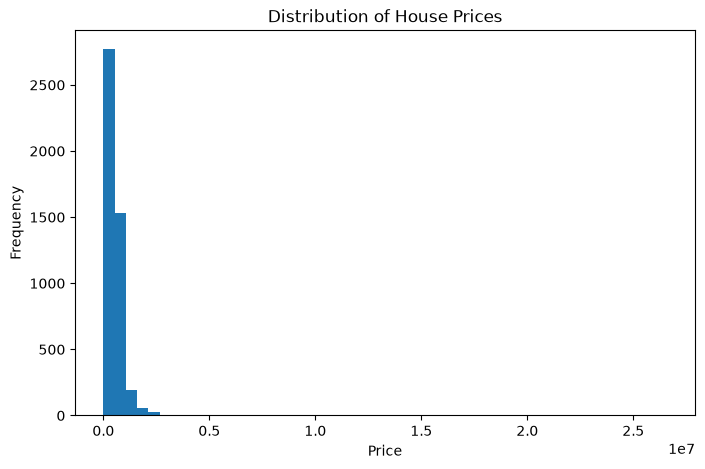

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=50)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

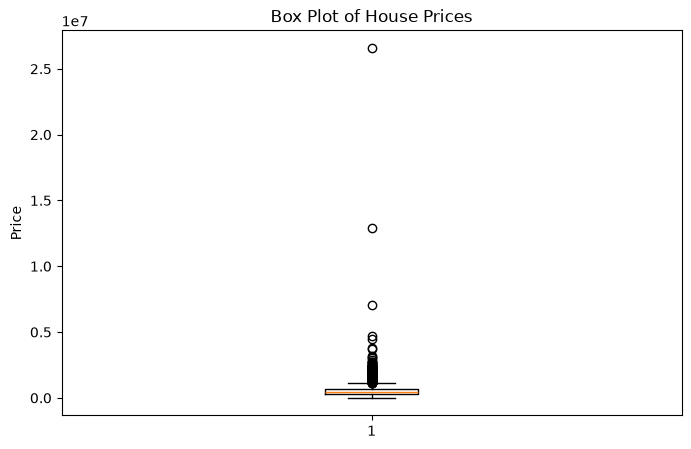

In [67]:
plt.figure(figsize=(8,5))
plt.boxplot(df["price"])
plt.title("Box Plot of House Prices")
plt.ylabel("Price")
plt.show()

In [68]:
df["price"].describe()

count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64

In [69]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

Lower Bound: -175256.25
Upper Bound: 1153093.75
Number of Outliers: 240


In [70]:
outliers[["price"]].head(10)

,price
1,2384000.0
11,1400000.0
14,1200000.0
99,1395000.0
122,2280000.0
133,1425000.0
193,1225000.0
201,1580000.0
217,1870000.0
227,1800000.0


In [71]:
df_clean = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
]

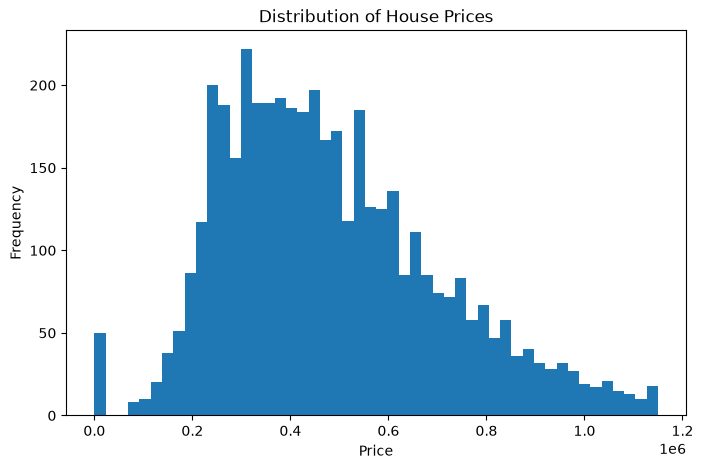

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["price"], bins=50)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [20]:
features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "yr_renovated"
]

target = "price"

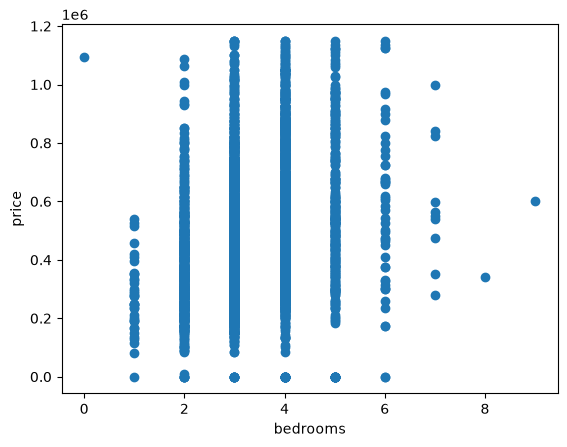

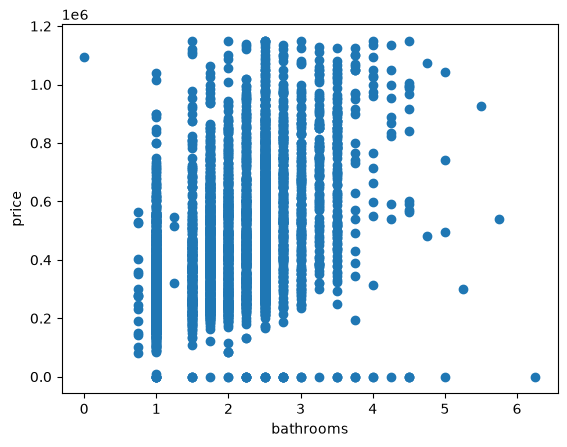

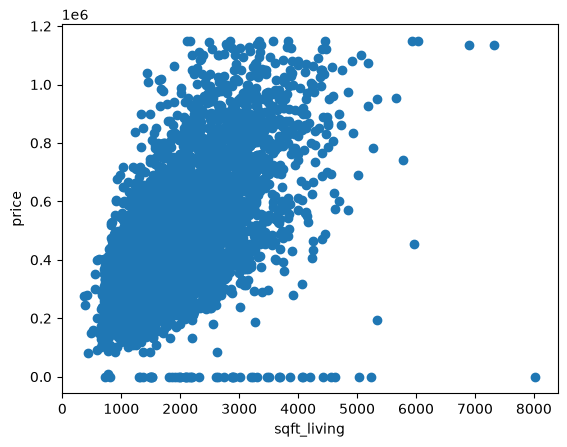

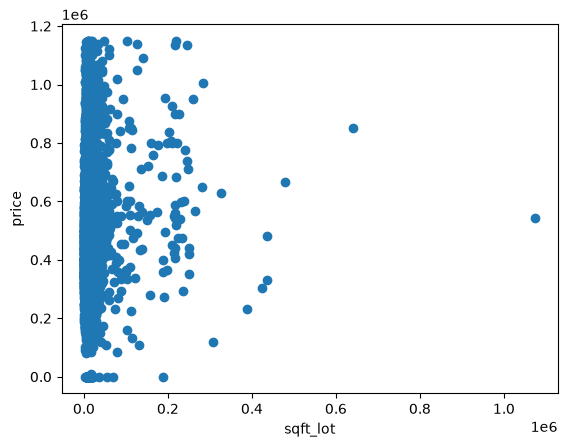

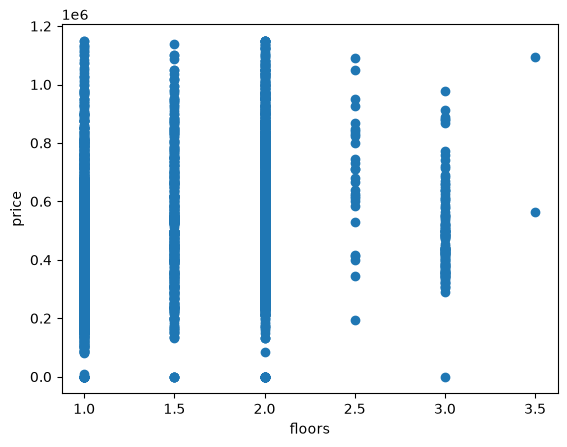

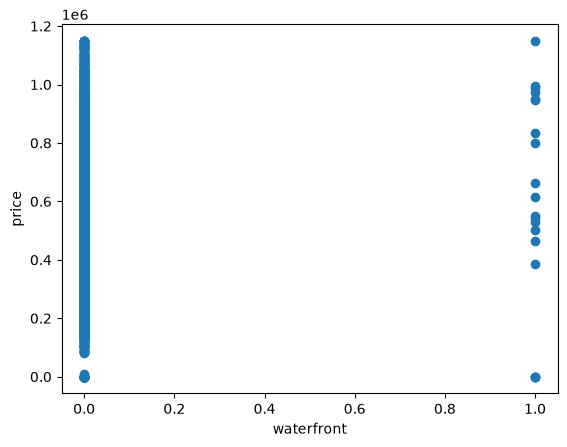

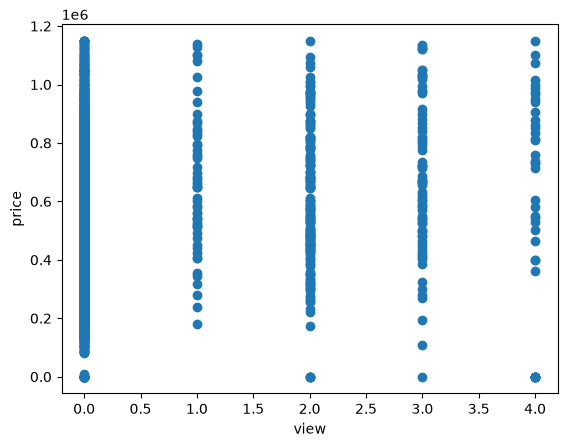

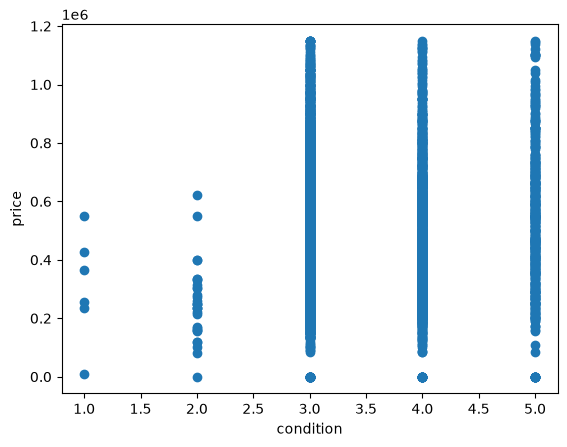

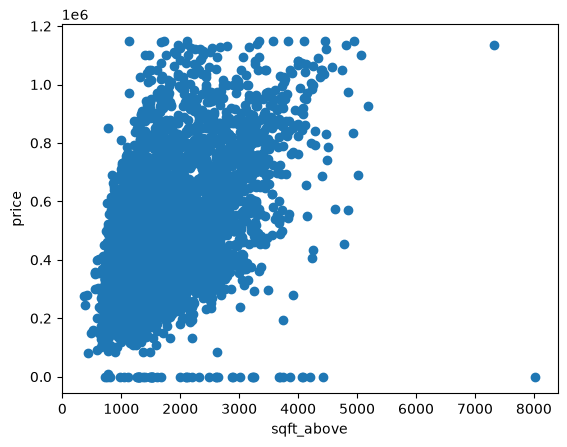

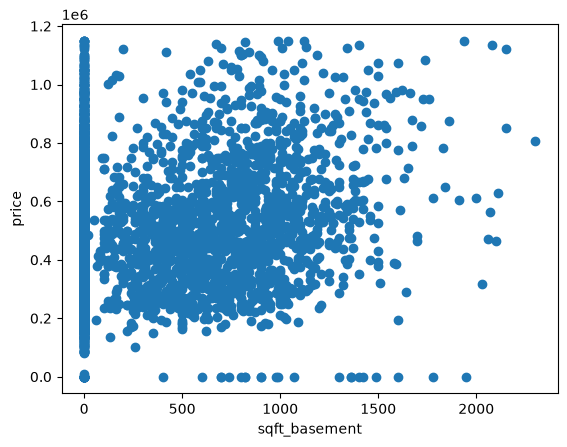

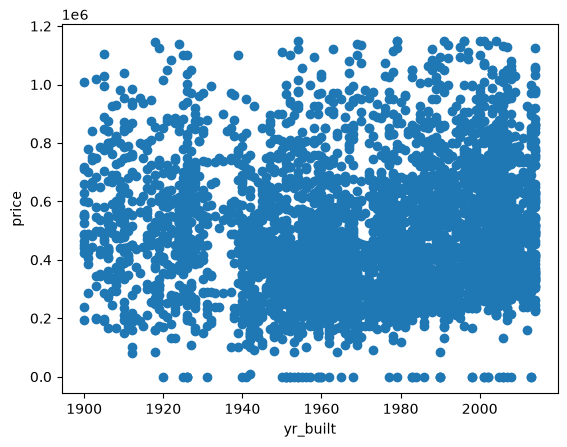

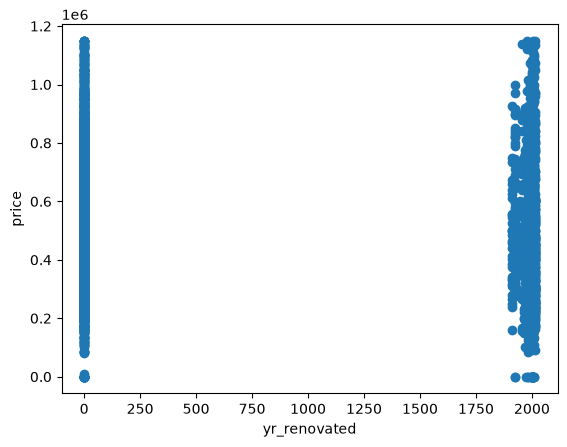

In [81]:
for feature in features:
    plt.scatter(df_clean[feature], df_clean["price"])
    plt.xlabel(feature)
    plt.ylabel("price")
    plt.show()

In [21]:
X = df_clean[features]
y = df_clean[target]

In [22]:
X.shape

(4360, 12)

In [23]:
y.shape

(4360,)

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create scaler
scaler = StandardScaler()

# Learn mean and standard deviation from training data only
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to the test data
X_test_scaled = scaler.transform(X_test)

In [25]:
X_train_scaled

array([[-0.42804185, -0.49652811, -0.94725069, ..., -0.67157689,
        -0.07605329, -0.81534525],
       [ 0.70302631, -0.49652811,  0.03798496, ...,  0.44308583,
        -0.24651587,  1.23181721],
       [ 1.83409446,  0.54281379,  0.20321082, ...,  1.9332139 ,
        -0.11014581, -0.81534525],
       ...,
       [-0.42804185,  0.54281379,  1.40262813, ..., -0.67157689,
         0.98081472, -0.81534525],
       [-0.42804185, -0.84297541, -0.31082517, ..., -0.67157689,
        -1.37156892, -0.81534525],
       [ 0.70302631,  0.54281379,  0.74172472, ..., -0.67157689,
         0.74216711, -0.81534525]], shape=(3488, 12))

In [26]:
import numpy as np

w_init = np.zeros(X_train_scaled.shape[1])
b_init = 0

In [27]:
w_init

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [28]:
def compute_cost(X, y, w, b):

    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        f_wb = np.dot(X[i],w) + b
        cost = cost + (f_wb - y[i])**2

    cost = cost / (2 * m)
    return cost


In [29]:
cost = compute_cost(X_train_scaled, y_train.values, w_init, b_init)

In [30]:
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 139648942147.83853


In [31]:
def compute_gradient(X, y, w, b):

    m,n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.0

    for i in range(m):
        f_wb = np.dot(X[i],w) + b
        err = f_wb - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err * X[i,j]
        dj_db = dj_db + err
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db


In [32]:
tmp_dj_dw, tmp_dj_db = compute_gradient(X_train_scaled, y_train.values, w_init, b_init)

In [33]:
print(f'dj_db at initial w,b: {tmp_dj_db}')

dj_db at initial w,b: -480546.41935431404


In [34]:
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_dw at initial w,b: 
 [ -61669.29131539  -95723.87853505 -127476.09669946  -20382.30531931
  -59928.12210431  -12972.27605887  -40120.75179787   -6309.20124854
 -110001.25052436  -44805.16848935  -16340.21407262   14479.42320898]


In [35]:
import math
import copy

def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_dw, dj_db = gradient_function(X, y, w, b)   ##None

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               ##None
        b = b - alpha * dj_db               ##None
      
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(X, y, w, b))

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}")
        
    return w, b, J_history #return final w,b and J history for graphing

In [ ]:
# some gradient descent settings
iterations = 1000
alpha = 5e-7 

In [37]:
w_final, b_final, J_hist = gradient_descent(X_train_scaled, y_train.values, w_init, b_init,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)

Iteration    0: Cost 139648801872.79
Iteration  100: Cost 139634775367.72
Iteration  200: Cost 139620750841.76
Iteration  300: Cost 139606728294.50
Iteration  400: Cost 139592707725.54
Iteration  500: Cost 139578689134.46
Iteration  600: Cost 139564672520.87
Iteration  700: Cost 139550657884.35
Iteration  800: Cost 139536645224.49
Iteration  900: Cost 139522634540.90


In [38]:
alpha = 1e-5

In [39]:
w_final, b_final, J_hist = gradient_descent(X_train_scaled, y_train.values, w_init, b_init,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)

Iteration    0: Cost 139646136665.71
Iteration  100: Cost 139365987764.99
Iteration  200: Cost 139086627404.19
Iteration  300: Cost 138808052348.31
Iteration  400: Cost 138530259380.89
Iteration  500: Cost 138253245303.89
Iteration  600: Cost 137977006937.53
Iteration  700: Cost 137701541120.22
Iteration  800: Cost 137426844708.40
Iteration  900: Cost 137152914576.41


In [40]:
alpha = 1e-4

In [41]:
w_final, b_final, J_hist = gradient_descent(X_train_scaled, y_train.values, w_init, b_init,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)

Iteration    0: Cost 139620889108.14
Iteration  100: Cost 136855027230.90
Iteration  200: Cost 134165173762.11
Iteration  300: Cost 131548332656.08
Iteration  400: Cost 129001672126.72
Iteration  500: Cost 126522513977.38
Iteration  600: Cost 124108323667.79
Iteration  700: Cost 121756701066.17
Iteration  800: Cost 119465371838.18
Iteration  900: Cost 117232179428.08


In [42]:
alpha = 5e-4

In [43]:
w_final, b_final, J_hist = gradient_descent(X_train_scaled, y_train.values, w_init, b_init,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)

Iteration    0: Cost 139508716539.75
Iteration  100: Cost 126421438353.88
Iteration  200: Cost 114963696592.08
Iteration  300: Cost 104863315115.63
Iteration  400: Cost 95909752513.35
Iteration  500: Cost 87937286673.44
Iteration  600: Cost 80813165232.62
Iteration  700: Cost 74429212947.98
Iteration  800: Cost 68695850107.28
Iteration  900: Cost 63537796555.72


In [44]:
alpha = 1e-3

In [45]:
w_final, b_final, J_hist = gradient_descent(X_train_scaled, y_train.values, w_init, b_init,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)

Iteration    0: Cost 139368589907.71
Iteration  100: Cost 114849546813.17
Iteration  200: Cost 95815592924.28
Iteration  300: Cost 80734717818.09
Iteration  400: Cost 68630029690.59
Iteration  500: Cost 58835477923.80
Iteration  600: Cost 50870479738.20
Iteration  700: Cost 44373048787.22
Iteration  800: Cost 39062223950.63
Iteration  900: Cost 34715575650.00


In [46]:
alpha = 5e-3

In [47]:
w_final, b_final, J_hist = gradient_descent(X_train_scaled, y_train.values, w_init, b_init,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)

Iteration    0: Cost 138251139988.84
Iteration  100: Cost 58393233021.45
Iteration  200: Cost 30962742055.92
Iteration  300: Cost 20855568522.46
Iteration  400: Cost 17077392599.70
Iteration  500: Cost 15644731301.63
Iteration  600: Cost 15089656616.45
Iteration  700: Cost 14867381641.43
Iteration  800: Cost 14773991489.43
Iteration  900: Cost 14732158040.09


In [48]:
iterations = 5000

In [49]:
w_final, b_final, J_hist = gradient_descent(X_train_scaled, y_train.values, w_init, b_init,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)

Iteration    0: Cost 138251139988.84
Iteration  500: Cost 15644731301.63
Iteration 1000: Cost 14711945756.46
Iteration 1500: Cost 14688503207.77
Iteration 2000: Cost 14686313394.06
Iteration 2500: Cost 14686041279.68
Iteration 3000: Cost 14686004317.78
Iteration 3500: Cost 14685998773.04
Iteration 4000: Cost 14685997823.29
Iteration 4500: Cost 14685997633.06


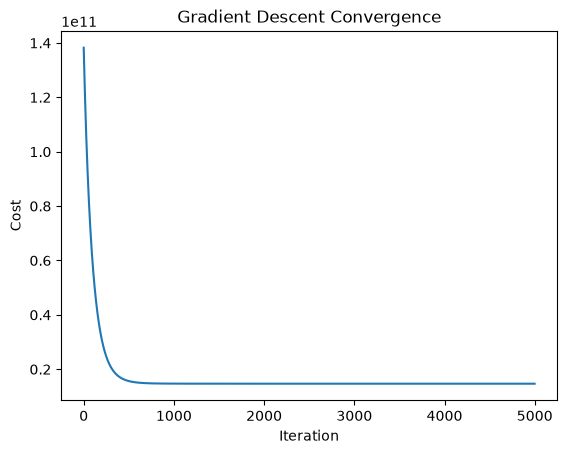

In [50]:
import matplotlib.pyplot as plt

plt.plot(J_hist)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")
plt.show()

In [51]:
y_pred = np.dot(X_test_scaled, w_final) + b_final

In [52]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,563000.0,634485.710776
1,740000.0,580499.958212
2,875000.0,477621.318262
3,402000.0,358054.223918
4,500000.0,427670.724974
5,270000.0,354157.985608
6,443000.0,453281.475687
7,288790.0,377331.147091
8,410000.0,390434.535235
9,316000.0,440769.348711


In [56]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 128964.58
RMSE: 171092.73
R²  : 0.4092
